# Notebook 04v2 — Modeling: Disaster-Level Classification (DRF Scope)

**Business question:** At the moment of federal declaration, which funding tier will this disaster ultimately reach?

**Model scope — Disaster Relief Fund (DRF) tiers only:**
- 0 = Minor (<\$1M) | 1 = Moderate (\$1M–\$50M) | 2 = Major (\$50M–\$500M)

**Why Tier 3 (Catastrophic >$500M) is excluded:**
FEMA's day-to-day operations are funded by the baseline **Disaster Relief Fund (DRF)**. Catastrophic events (Tier 3) are black-swan occurrences that exhaust the DRF and trigger **Congressional Emergency Supplemental Appropriations** — a separate, extraordinary funding mechanism. Including Tier 3 in the model would generate false positives that incorrectly reserve DRF budget for rare events the DRF was never designed to cover, degrading planning accuracy for the core 96% of disasters.

**Features used:** Only information available at declaration time — no post-event financial data, no project counts.

**Structure:**
1. Define features & target
2. Three-way temporal split (train / val / test)
3. Preprocessing pipeline
4. Train & evaluate 4 models
5. Hyperparameter tuning — Gradient Boosting
6. Bootstrap stability analysis
7. Results summary table + per-class breakdown
8. Feature importances + confusion matrix
9. Save best pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
sys.path.append('../')
from utils import classification_metrics, DISASTER_LABELS

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone

PROCESSED = '../data/processed/'
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Disaster-level shape:', disas.shape)
print('Target distribution:')
print(disas['funding_tier'].value_counts().sort_index())

Disaster-level shape: (1766, 21)
Target distribution:
funding_tier
0     145
1    1296
2     254
3      71
Name: count, dtype: int64


## 4.1 Define Features & Target

Only features known **at declaration time** are included.

| Feature | Type | Available at declaration? |
|---|---|---|
| `incidentType` | Categorical | Yes — stated in declaration |
| `stateAbbreviation` | Categorical | Yes — stated in declaration |
| `incident_season` | Categorical | Yes — derived from incident start date |
| `declaration_lag_days` | Numeric | Yes — time from incident start to declaration |
| `incident_duration_days` | Numeric | Yes — most incidents end within days of declaration |
| `n_counties` | Numeric | Yes — counties designated in declaration |
| `prior_disasters_5yr` | Numeric | Yes — historical record, known in advance |
| `population` | Numeric | Yes — Census, static |
| `median_income` | Numeric | Yes — Census, static |
| `poverty_rate` | Numeric | Yes — Census, static |
| `risk_score` | Numeric | Yes — NRI, static |

`n_projects` is **excluded**: the number of PA applications only becomes known 12–18 months after declaration.

**Tier 3 (Catastrophic >$500M) rows are excluded** from modeling: these 71 events (~4% of data) are funded via Congressional Emergency Supplemental Appropriations, not the DRF. Including them would distort DRF budget planning with false positive catastrophic flags.

In [ ]:
CAT_FEATURES = ['incidentType', 'stateAbbreviation', 'incident_season']
NUM_FEATURES = [
    'declaration_lag_days',
    'incident_duration_days',
    'n_counties',
    'prior_disasters_5yr',
    'population',
    'median_income',
    'poverty_rate',
    'risk_score',
]
TARGET = 'funding_tier'

CAT_FEATURES = [c for c in CAT_FEATURES if c in disas.columns]
NUM_FEATURES = [c for c in NUM_FEATURES if c in disas.columns]
FEATURES     = CAT_FEATURES + NUM_FEATURES

df_model = disas[FEATURES + [TARGET, 'incident_year']].dropna(subset=[TARGET])
df_model[TARGET] = df_model[TARGET].astype(int)

# ── DRF scope: exclude Tier 3 (Catastrophic >$500M) ──────────────────────────
# These black-swan events are funded by Congressional Emergency Supplemental
# Appropriations, not the DRF. Including them would generate false positives
# that misallocate baseline DRF budget.
tier3_count = (df_model[TARGET] == 3).sum()
df_model = df_model[df_model[TARGET] <= 2].copy()
print(f'Tier 3 rows excluded (Congressional supplemental scope): {tier3_count}')

print(f'Modeling rows: {len(df_model):,}  |  Features: {len(FEATURES)}')
print('Categorical:', CAT_FEATURES)
print('Numeric:    ', NUM_FEATURES)
print('\nClass distribution (DRF tiers only):')
for t, n in df_model[TARGET].value_counts().sort_index().items():
    print(f'  Tier {t}  {DISASTER_LABELS[t]:<28}  {n:>5,}  ({100*n/len(df_model):.1f}%)')

## 4.2 Three-Way Temporal Train / Validation / Test Split

A random split would allow the model to train on 2020 disasters and test on 2005 ones — leaking future patterns into training. The temporal split prevents this by strictly ordering data by time.

| Set | Years | Purpose |
|---|---|---|
| **Train** | pre-2016 | Fit all models |
| **Validation** | 2016–2017 | Select best model — never used to fit |
| **Test** | 2018+ | Final reported metrics — touched once at the end |

In [3]:
VALIDATION_YEAR = 2016
SPLIT_YEAR      = 2018

train = df_model[df_model['incident_year'] <  VALIDATION_YEAR]
val   = df_model[(df_model['incident_year'] >= VALIDATION_YEAR) &
                 (df_model['incident_year'] <  SPLIT_YEAR)]
test  = df_model[df_model['incident_year'] >= SPLIT_YEAR]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train : {len(X_train):,}  ({train["incident_year"].min()}–{train["incident_year"].max()})')
print(f'Val   : {len(X_val):,}    ({val["incident_year"].min()}–{val["incident_year"].max()})')
print(f'Test  : {len(X_test):,}   ({test["incident_year"].min()}–{test["incident_year"].max()})')

Train : 1,102  (1998–2015)
Val   : 100    (2016–2017)
Test  : 564   (2018–2026)


## 4.3 Preprocessing Pipeline

All preprocessing is wrapped in an sklearn `Pipeline` so the same transformations apply consistently to train, val, and test without any data from val/test influencing the fitted transformers.

- **Categorical:** impute missing with `'Unknown'` → one-hot encode (unknown categories at test time are silently ignored)
- **Numeric:** impute missing with median → standardise (zero mean, unit variance)

In [4]:
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
])
print('Preprocessor defined.')

Preprocessor defined.


## 4.4 Train & Evaluate Four Models

Four algorithms are trained and evaluated:
- **Stratified Baseline** — always predicts the most common class proportionally; sets the floor any real model must beat
- **Logistic Regression** — linear benchmark; interpretable coefficients
- **Random Forest** — ensemble of decision trees; handles non-linearity and class imbalance via `class_weight='balanced'`
- **Gradient Boosting** — sequential ensemble; typically strongest on small tabular datasets

Each model is evaluated on **validation** (for selection) and **test** (for final reporting). Test metrics are computed here but not used for any decision until §4.7.

In [ ]:
TARGET_NAMES = [DISASTER_LABELS[i] for i in range(3)]  # DRF tiers only (0, 1, 2)

models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression':   LogisticRegression(max_iter=1000, class_weight='balanced',
                                                random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results_val      = {}   # val metrics  — used for model selection
results_disaster = {}   # test metrics — used for final reporting only

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    val_preds  = pipe.predict(X_val)
    m_val      = classification_metrics(y_val.values, val_preds, label=name,
                                        target_names=TARGET_NAMES)
    results_val[name] = {**m_val, 'pipeline': pipe, 'preds': val_preds}

    test_preds = pipe.predict(X_test)
    m_test     = classification_metrics(y_test.values, test_preds, label=name,
                                        target_names=TARGET_NAMES)
    m_test['pipeline'] = pipe
    m_test['preds']    = test_preds
    results_disaster[name] = m_test

    print(f'{name:<30}  val F1={m_val["F1_weighted"]:.4f}  |  test F1={m_test["F1_weighted"]:.4f}')

## 4.5 Hyperparameter Tuning — Gradient Boosting

Gradient Boosting is the strongest default model on small tabular datasets. We tune it using `RandomizedSearchCV` with `TimeSeriesSplit(n_splits=5)` so that even the internal cross-validation folds respect temporal order — no future leakage within the training set.

The search runs 30 random combinations over the parameter grid. The best estimator is then evaluated on `X_val` (for model selection) and `X_test` (for final reporting), and added to `results_val` and `results_disaster` alongside the baseline models.

In [6]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'model__n_estimators':      [100, 200, 300, 400],
    'model__max_depth':         [3, 4, 5, 6],
    'model__learning_rate':     [0.05, 0.1, 0.15, 0.2],
    'model__min_samples_split': [2, 5, 10],
    'model__subsample':         [0.7, 0.8, 1.0],
}

gb_base_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

search = RandomizedSearchCV(
    gb_base_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print('\nBest params:', search.best_params_)
print(f'Best CV F1 (train folds): {search.best_score_:.4f}')

# Validation — for model selection
tuned_val_preds = search.best_estimator_.predict(X_val)
m_tuned_val = classification_metrics(y_val.values, tuned_val_preds,
                                      label='GradBoosting (Tuned)',
                                      target_names=TARGET_NAMES)
results_val['GradBoosting (Tuned)'] = {
    **m_tuned_val, 'pipeline': search.best_estimator_, 'preds': tuned_val_preds
}

# Test — final reporting only
tuned_test_preds = search.best_estimator_.predict(X_test)
m_tuned_test = classification_metrics(y_test.values, tuned_test_preds,
                                       label='GradBoosting (Tuned)',
                                       target_names=TARGET_NAMES)
m_tuned_test['pipeline'] = search.best_estimator_
m_tuned_test['preds']    = tuned_test_preds
results_disaster['GradBoosting (Tuned)'] = m_tuned_test

print(f'\nTuned — Val  F1_weighted: {m_tuned_val["F1_weighted"]:.4f}')
print(f'Tuned — Test F1_weighted: {m_tuned_test["F1_weighted"]:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__max_depth': 4, 'model__learning_rate': 0.2}
Best CV F1 (train folds): 0.7995

  GradBoosting (Tuned)
  Accuracy   :   0.7400
  F1 (wtd)   :   0.6872

                       precision    recall  f1-score   support

         Minor (<$1M)       0.60      0.75      0.67         4
  Moderate ($1M–$50M)       0.80      0.96      0.87        69
   Major ($50M–$500M)       0.42      0.26      0.32        19
Catastrophic (>$500M)       0.00      0.00      0.00         8

             accuracy                           0.74       100
            macro avg       0.45      0.49      0.46       100
         weighted avg       0.65      0.74      0.69       100


  GradBoosting (Tuned)
  Accuracy   :   0.6773
  F1 (wtd)   :   0.6283

                       precision    recall  f1-score   support

         Minor (<$1M)       0.64    

## 4.6 Bootstrap Stability Analysis

With only ~1,000 training rows a single train/test split produces a point estimate of F1 that may be lucky or unlucky. Bootstrap resampling quantifies how stable the result is.

**Method:** resample the training set **with replacement** 50 times → refit the val-selected best model on each resample → evaluate on the same fixed test set → report mean ± standard deviation and 95% confidence interval.

A tight CI (e.g. ±0.03) confirms the result is not a fluke of one particular split.

Bootstrapping: Logistic Regression

Bootstrap F1_weighted over 50 resamples:
  Mean  : 0.6163
  Std   : 0.0123
  95% CI: [0.5937,  0.6419]


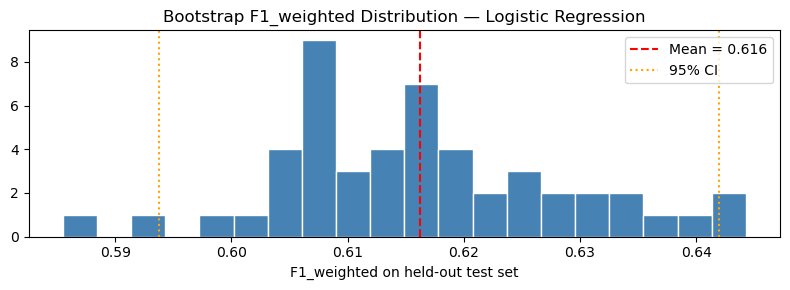

In [7]:
N_BOOTSTRAP = 50
rng = np.random.default_rng(42)
bootstrap_f1 = []

best_name_boot = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
best_pipe_boot = results_val[best_name_boot]['pipeline']
print(f'Bootstrapping: {best_name_boot}')

for _ in range(N_BOOTSTRAP):
    idx      = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_boot   = X_train.iloc[idx]
    y_boot   = y_train.iloc[idx]
    pipe_b   = clone(best_pipe_boot)
    pipe_b.fit(X_boot, y_boot)
    preds_b  = pipe_b.predict(X_test)
    bootstrap_f1.append(f1_score(y_test, preds_b, average='weighted', zero_division=0))

bootstrap_f1 = np.array(bootstrap_f1)
print(f'\nBootstrap F1_weighted over {N_BOOTSTRAP} resamples:')
print(f'  Mean  : {bootstrap_f1.mean():.4f}')
print(f'  Std   : {bootstrap_f1.std():.4f}')
print(f'  95% CI: [{np.percentile(bootstrap_f1, 2.5):.4f},  {np.percentile(bootstrap_f1, 97.5):.4f}]')

plt.figure(figsize=(8, 3))
plt.hist(bootstrap_f1, bins=20, color='steelblue', edgecolor='white')
plt.axvline(bootstrap_f1.mean(), color='red', linestyle='--',
            label=f'Mean = {bootstrap_f1.mean():.3f}')
plt.axvline(np.percentile(bootstrap_f1, 2.5),  color='orange', linestyle=':', label='95% CI')
plt.axvline(np.percentile(bootstrap_f1, 97.5), color='orange', linestyle=':')
plt.title(f'Bootstrap F1_weighted Distribution — {best_name_boot}')
plt.xlabel('F1_weighted on held-out test set')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/bootstrap_f1_disaster.png', dpi=150)
plt.show()

## 4.7 Results Summary Table + Per-Class Breakdown

**Model selection uses validation F1** (2016–2017 holdout). Test F1 (2018+) is reported here for the first and only time.

The per-class breakdown is critical for the business case: **Tier 2 (Major)** recall tells us how often the model correctly flags the highest-cost DRF events before the budget is set. This is the most consequential tier within DRF scope — an under-prediction here means FEMA under-reserves from its baseline fund.

(Tier 3 Catastrophic is intentionally excluded — those events activate Congressional supplemental appropriations, not the DRF.)

In [8]:
# Overall summary across all models
summary = pd.DataFrame([
    {
        'Model':    name,
        'Val F1':   round(results_val[name]['F1_weighted'], 4) if name in results_val else '-',
        'Test F1':  round(results_disaster[name]['F1_weighted'], 4),
        'Test Acc': round(results_disaster[name]['Accuracy'], 4),
    }
    for name in results_disaster
]).set_index('Model')
display(summary)

# Per-class breakdown for val-selected best model
best_name = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
print(f'\nBest model (by val F1): {best_name}')
print(f'Per-class report on test set:')
report_df = pd.DataFrame(
    classification_report(
        y_test,
        results_disaster[best_name]['preds'],
        target_names=TARGET_NAMES,
        zero_division=0,
        output_dict=True
    )
).T.round(3)
display(report_df)

,Val F1,Test F1,Test Acc
Model,,,
Baseline (Stratified),0.4993,0.4365,0.4982
Logistic Regression,0.7291,0.6232,0.6294
Random Forest,0.6842,0.5077,0.6223
Gradient Boosting,0.6922,0.6259,0.6773
GradBoosting (Tuned),0.6872,0.6283,0.6773



Best model (by val F1): Logistic Regression
Per-class report on test set:


,precision,recall,f1-score,support
Minor (<$1M),0.421,0.632,0.505,76.000
Moderate ($1M–$50M),0.792,0.741,0.766,340.000
Major ($50M–$500M),0.467,0.206,0.286,102.000
Catastrophic (>$500M),0.391,0.739,0.511,46.000
accuracy,0.629,0.629,0.629,0.629
macro avg,0.518,0.579,0.517,564.000
weighted avg,0.651,0.629,0.623,564.000


## 4.8 Feature Importances + Confusion Matrix

**Feature importances** show which inputs drive predictions most — useful for validating that the model is learning from domain-relevant signals (incident type, affected counties) rather than noise.

**Confusion matrix** shows where errors occur. Adjacent-tier errors (predicting Moderate when true is Major) are acceptable. Cross-tier errors (predicting Minor when true is Catastrophic) represent the costliest planning failures.

Logistic Regression does not expose feature_importances_ — skipping plot.


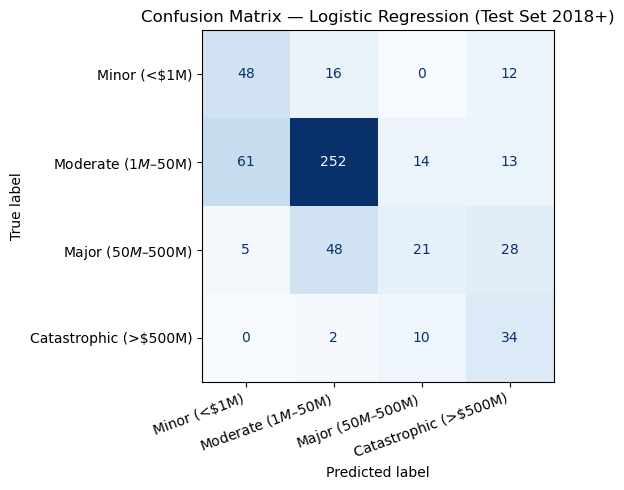

In [9]:
best_name  = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
best_pipe  = results_disaster[best_name]['pipeline']
best_model = best_pipe.named_steps['model']
best_pre   = best_pipe.named_steps['pre']

ohe_names = best_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names  = list(ohe_names) + NUM_FEATURES

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=all_names)
    importances.nlargest(20).sort_values().plot(
        kind='barh', figsize=(10, 6),
        title=f'Top 20 Feature Importances — {best_name}',
        color='steelblue'
    )
    plt.tight_layout()
    plt.savefig('../data/processed/feature_importance_disaster.png', dpi=150)
    plt.show()
else:
    print(f'{best_name} does not expose feature_importances_ — skipping plot.')

# Confusion matrix — val-selected best model on test set
cm = confusion_matrix(y_test, results_disaster[best_name]['preds'])
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (Test Set 2018+)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_disaster.png', dpi=150)
plt.show()

## 4.9 Save Best Pipeline

The best model (selected by **validation F1**) is saved as a pickle bundle.
The bundle includes everything nb06 needs to produce evaluation outputs without re-running the training.

In [10]:
best_name = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
print(f'Best model (val F1):   {best_name}')
print(f'  Val  F1_weighted : {results_val[best_name]["F1_weighted"]:.4f}')
print(f'  Test F1_weighted : {results_disaster[best_name]["F1_weighted"]:.4f}')

with open(PROCESSED + 'best_disaster_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':     results_disaster[best_name]['pipeline'],
        'X_test':       X_test,
        'y_test':       y_test,
        'preds':        results_disaster[best_name]['preds'],
        'val_f1':       results_val[best_name]['F1_weighted'],
        'test_f1':      results_disaster[best_name]['F1_weighted'],
        'features':     FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'target_names': TARGET_NAMES,
        'model_name':   best_name,
        'level':        'disaster',
    }, f)
print('Saved: best_disaster_model.pkl')

Best model (val F1):   Logistic Regression
  Val  F1_weighted : 0.7291
  Test F1_weighted : 0.6232
Saved: best_disaster_model.pkl
